## Part 1: The Core Simulation Engine

In [9]:
import numpy as np
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import pandas as pd
from IPython.display import display, HTML

# 1. Base Parameters from Avellaneda-Stoikov (2006)
s_0 = 100.0       
T = 1.0           
sigma = 2.0       
dt = 0.005        
k = 1.5           
A = 140.0         
simulations = 1000 
N = int(T / dt)   
time_grid = np.linspace(0, T, N)

def simulate_market_maker(strategy="inventory", ask_multiplier=1.0, bid_multiplier=1.0, jump_diffusion=False, gamma=0.1):
    S = np.zeros(N)
    S[0] = s_0
    q = np.zeros(N)  
    X = np.zeros(N)  
    
    # Tracking arrays for Graph 1
    r_track = np.zeros(N)
    p_a_track = np.zeros(N)
    p_b_track = np.zeros(N)
    
    for i in range(N - 1):
        t = time_grid[i]
        
        r = S[i] - q[i] * gamma * (sigma ** 2) * (T - t) 
        optimal_spread = gamma * (sigma ** 2) * (T - t) + (2 / gamma) * np.log(1 + gamma / k)
        
        if strategy == "inventory":
            p_a = r + optimal_spread / 2
            p_b = r - optimal_spread / 2
        else: 
            p_a = S[i] + optimal_spread / 2
            p_b = S[i] - optimal_spread / 2
            
        r_track[i] = r
        p_a_track[i] = p_a
        p_b_track[i] = p_b
        
        delta_a = p_a - S[i]
        delta_b = S[i] - p_b
        
        lambda_a = A * np.exp(-k * delta_a) * ask_multiplier
        lambda_b = A * np.exp(-k * delta_b) * bid_multiplier
        
        if np.random.rand() < (lambda_a * dt):
            q[i+1] = q[i] - 1
            X[i+1] = X[i] + p_a
        else:
            q[i+1] = q[i]
            X[i+1] = X[i]
            
        if np.random.rand() < (lambda_b * dt):
            q[i+1] = q[i+1] + 1
            X[i+1] = X[i+1] - p_b
            
        price_shock = np.random.choice([1, -1]) * sigma * np.sqrt(dt) 
        if jump_diffusion and np.random.rand() < (5 * dt): 
            price_shock += np.random.choice([1, -1]) * np.random.exponential(1.5)
            
        S[i+1] = S[i] + price_shock
        
    # Carry forward final step for trackers
    r_track[-1], p_a_track[-1], p_b_track[-1] = r_track[-2], p_a_track[-2], p_b_track[-2]
    PnL = X + q * S
    
    return time_grid, S, q, X, PnL, r_track, p_a_track, p_b_track

## Part 2: Running the Monte Carlo & Generating Visualizations
This block runs both strategies 1,000 times, computes the performance metrics required (Profit, Std Dev, Final $q$), and generates the visualizations.

Running simulations, please wait...


Strategy,Mean Profit,Std Dev (Profit),Mean Final q,Std Dev (Final q),Sharpe Ratio
Inventory,64.637,6.584,-0.020,2.945,9.818
Symmetric,67.311,12.738,0.397,8.327,5.284


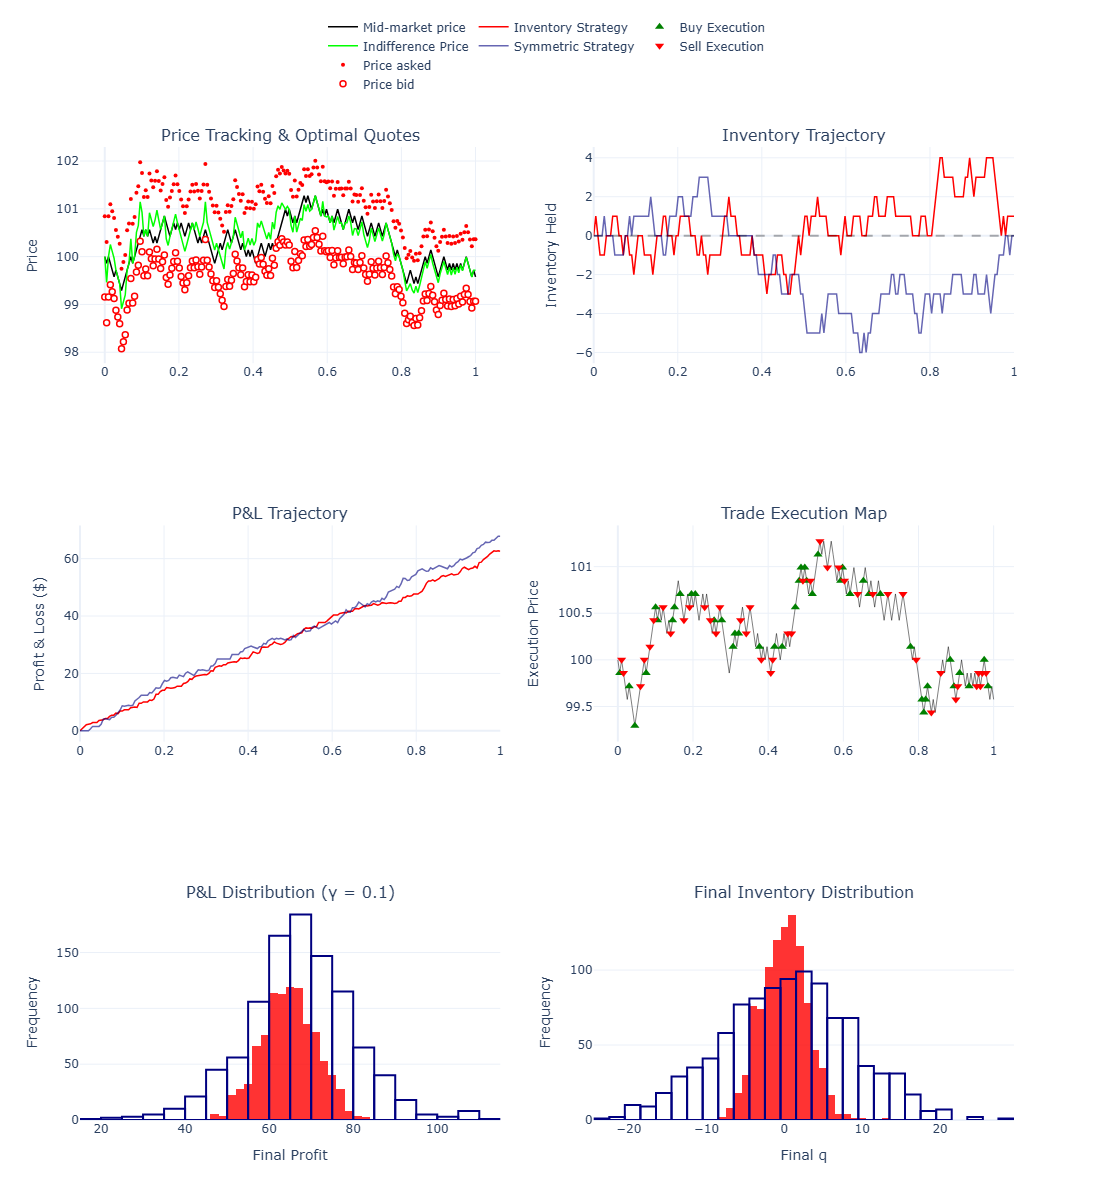

In [10]:
def run_monte_carlo(ask_mult=1.0, bid_mult=1.0, jumps=False, gamma_val=0.1):
    results = {"inventory": {"pnl": [], "final_q": []}, 
               "symmetric": {"pnl": [], "final_q": []}}
    
    sample_paths = {}
    
    for strat in ["inventory", "symmetric"]:
        for i in range(simulations):
            t, S, q, X, PnL, r_t, p_a_t, p_b_t = simulate_market_maker(
                strategy=strat, ask_multiplier=ask_mult, bid_multiplier=bid_mult, jump_diffusion=jumps, gamma=gamma_val
            )
            results[strat]["pnl"].append(PnL[-1])
            results[strat]["final_q"].append(q[-1])
            
            if i == 0:
                sample_paths[strat] = (t, S, q, PnL, r_t, p_a_t, p_b_t)
                
    # Calculate Risk Metrics
    metrics = []
    for strat in ["inventory", "symmetric"]:
        pnl_array = np.array(results[strat]["pnl"])
        q_array = np.array(results[strat]["final_q"])
        
        metrics.append({
            "Strategy": strat.capitalize(),
            "Mean Profit": np.mean(pnl_array),
            "Std Dev (Profit)": np.std(pnl_array),
            "Mean Final q": np.mean(q_array),
            "Std Dev (Final q)": np.std(q_array),
            "Sharpe Ratio": np.mean(pnl_array) / np.std(pnl_array) if np.std(pnl_array) > 0 else 0
        })
        
    df_metrics = pd.DataFrame(metrics)
    
    # Style, format to 3 decimals, and center the HTML table
    styled_df = df_metrics.style.format(precision=3) \
        .set_table_attributes('style="margin-left: auto; margin-right: auto; width: 80%;"') \
        .set_properties(**{'text-align': 'center'}) \
        .hide(axis='index')
    
    display(HTML("<h3 style='text-align: center;'>Performance Metrics</h3>"))
    display(HTML(styled_df.to_html()))
    
    # --- Visualizations (Plotly 6-Panel Layout) ---
    t, S, q, PnL, r_t, p_a_t, p_b_t = sample_paths["inventory"]
    
    fig = make_subplots(
        rows=3, cols=2, 
        subplot_titles=(
            "Price Tracking & Optimal Quotes", 
            "Inventory Trajectory", 
            "P&L Trajectory", 
            "Trade Execution Map", 
            f"P&L Distribution (\u03B3 = {gamma_val})", 
            "Final Inventory Distribution"
        )
    )

    # Clean Hover Templates (Name in Bold, 3 decimal places, no side-box)
    hover_price = '<b>%{data.name}</b><br>Time: %{x:.3f}<br>Price: %{y:.3f}<extra></extra>'
    hover_inv   = '<b>%{data.name}</b><br>Time: %{x:.3f}<br>Inventory: %{y:.3f}<extra></extra>'
    hover_pnl   = '<b>%{data.name}</b><br>Time: %{x:.3f}<br>P&L: $%{y:.3f}<extra></extra>'
    hover_dist  = '<b>%{data.name}</b><br>P&L: %{x:.3f}<br>Count: %{y}<extra></extra>'
    hover_distq = '<b>%{data.name}</b><br>Final Q: %{x:.3f}<br>Count: %{y}<extra></extra>'

    # 1. Price Tracking (Row 1, Col 1)
    fig.add_trace(go.Scatter(x=t, y=S, mode='lines', name='Mid-market price', line=dict(color='black', width=1.5), hovertemplate=hover_price, legendgroup="price"), row=1, col=1)
    fig.add_trace(go.Scatter(x=t, y=r_t, mode='lines', name='Indifference Price', line=dict(color='lime', width=1.5), hovertemplate=hover_price, legendgroup="price"), row=1, col=1)
    fig.add_trace(go.Scatter(x=t, y=p_a_t, mode='markers', name='Price asked', marker=dict(color='red', size=4), hovertemplate=hover_price, legendgroup="price"), row=1, col=1)
    fig.add_trace(go.Scatter(x=t, y=p_b_t, mode='markers', name='Price bid', marker=dict(color='white', line=dict(color='red', width=1.5), size=6), hovertemplate=hover_price, legendgroup="price"), row=1, col=1)

    # 2. Inventory Trajectory (Row 1, Col 2)
    fig.add_trace(go.Scatter(x=t, y=q, mode='lines', name='Inventory Strategy', line=dict(color='red', width=1.5), hovertemplate=hover_inv, legendgroup="inv"), row=1, col=2)
    fig.add_trace(go.Scatter(x=t, y=sample_paths["symmetric"][2], mode='lines', name='Symmetric Strategy', line=dict(color='navy', width=1.5), opacity=0.6, hovertemplate=hover_inv, legendgroup="inv"), row=1, col=2)
    fig.add_hline(y=0, line_dash="dash", line_color="black", opacity=0.3, row=1, col=2)

    # 3. P&L Trajectory (Row 2, Col 1)
    fig.add_trace(go.Scatter(x=t, y=PnL, mode='lines', name='Inventory Strategy P&L', line=dict(color='red', width=1.5), hovertemplate=hover_pnl, legendgroup="pnl", showlegend=False), row=2, col=1)
    fig.add_trace(go.Scatter(x=t, y=sample_paths["symmetric"][3], mode='lines', name='Symmetric Strategy P&L', line=dict(color='navy', width=1.5), opacity=0.6, hovertemplate=hover_pnl, legendgroup="pnl", showlegend=False), row=2, col=1)

    # 4. Trade Execution Map (Row 2, Col 2)
    buy_idx = np.where(np.diff(q) > 0)[0] + 1
    sell_idx = np.where(np.diff(q) < 0)[0] + 1
    
    fig.add_trace(go.Scatter(x=t, y=S, mode='lines', name='Mid-Price', line=dict(color='black', width=1.0), opacity=0.5, hovertemplate=hover_price, legendgroup="exec", showlegend=False), row=2, col=2)
    fig.add_trace(go.Scatter(x=t[buy_idx], y=S[buy_idx], mode='markers', name='Buy Execution', marker=dict(symbol='triangle-up', color='green', size=8), hovertemplate=hover_price, legendgroup="exec"), row=2, col=2)
    fig.add_trace(go.Scatter(x=t[sell_idx], y=S[sell_idx], mode='markers', name='Sell Execution', marker=dict(symbol='triangle-down', color='red', size=8), hovertemplate=hover_price, legendgroup="exec"), row=2, col=2)

    # 5. P&L Histogram (Row 3, Col 1)
    fig.add_trace(go.Histogram(x=results["inventory"]["pnl"], nbinsx=30, name='Inventory Strategy', marker_color='red', opacity=0.8, hovertemplate=hover_dist, legendgroup="dist", showlegend=False), row=3, col=1)
    fig.add_trace(go.Histogram(x=results["symmetric"]["pnl"], nbinsx=30, name='Symmetric Strategy', marker=dict(color='rgba(0,0,0,0)', line=dict(color='navy', width=2)), hovertemplate=hover_dist, legendgroup="dist", showlegend=False), row=3, col=1)

    # 6. Final Inventory Histogram (Row 3, Col 2)
    fig.add_trace(go.Histogram(x=results["inventory"]["final_q"], nbinsx=30, name='Inventory Strategy', marker_color='red', opacity=0.8, hovertemplate=hover_distq, legendgroup="dist_q", showlegend=False), row=3, col=2)
    fig.add_trace(go.Histogram(x=results["symmetric"]["final_q"], nbinsx=30, name='Symmetric Strategy', marker=dict(color='rgba(0,0,0,0)', line=dict(color='navy', width=2)), hovertemplate=hover_distq, legendgroup="dist_q", showlegend=False), row=3, col=2)

    # Update global layout
    fig.update_layout(
        height=1200, 
        autosize=True,
        template="plotly_white",
        barmode='overlay', 
        hovermode="closest",
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.05,
            xanchor="center",
            x=0.5
        )
    )

    # Add axis titles
    fig.update_yaxes(title_text="Price", row=1, col=1)
    fig.update_yaxes(title_text="Inventory Held", row=1, col=2)
    fig.update_yaxes(title_text="Profit & Loss ($)", row=2, col=1)
    fig.update_yaxes(title_text="Execution Price", row=2, col=2)
    fig.update_xaxes(title_text="Final Profit", row=3, col=1)
    fig.update_yaxes(title_text="Frequency", row=3, col=1)
    fig.update_xaxes(title_text="Final q", row=3, col=2)
    fig.update_yaxes(title_text="Frequency", row=3, col=2)

    fig.show()

# Execute the plot
run_monte_carlo(gamma_val=0.1)

In [11]:
def evaluate_gamma_impact():
    gamma_values = [0.01, 0.1, 0.5]
    metrics = []
    
    for g in gamma_values:
        for strat in ["inventory", "symmetric"]:
            pnl_list = []
            for _ in range(simulations):
                _, _, _, _, PnL, _, _, _ = simulate_market_maker(strategy=strat, gamma=g)
                pnl_list.append(PnL[-1])
            
            pnl_array = np.array(pnl_list)
            metrics.append({
                "Gamma (γ)": g,
                "Strategy": strat.capitalize(),
                "Mean Profit": np.mean(pnl_array),
                "Std Dev (Profit)": np.std(pnl_array),
                "Sharpe Ratio": np.mean(pnl_array) / np.std(pnl_array) if np.std(pnl_array) > 0 else 0
            })
            
    df_gamma = pd.DataFrame(metrics)
    
    # Style and center the table
    styled_df = df_gamma.style.format({
        "Gamma (γ)": "{:.2f}",
        "Mean Profit": "{:.3f}",
        "Std Dev (Profit)": "{:.3f}",
        "Sharpe Ratio": "{:.3f}"
    }).set_table_attributes('style="margin-left: auto; margin-right: auto; width: 60%;"') \
      .set_properties(**{'text-align': 'center'}) \
      .hide(axis='index')
    
    display(HTML("<h3 style='text-align: center;'>Impact of Risk Aversion (γ)</h3>"))
    display(HTML(styled_df.to_html()))

evaluate_gamma_impact()

Gamma (γ),Strategy,Mean Profit,Std Dev (Profit),Sharpe Ratio
0.01,Inventory,68.468,8.989,7.617
0.01,Symmetric,68.406,13.577,5.039
0.10,Inventory,64.760,6.844,9.462
0.10,Symmetric,67.693,12.634,5.358
0.50,Inventory,48.177,5.871,8.205
0.50,Symmetric,58.386,12.147,4.807


## Part 3: Adding Asymmetric "Toxic" Order Flow

The base paper assumes buyers and sellers arrive identically. In reality, order flow becomes "toxic" when the market develops a sudden trend (e.g., news breaks, and aggressive buyers swarm the market). A naive symmetric strategy will blindly sell to all these buyers, accumulating a massive, dangerous short position.

Running simulations, please wait...


Strategy,Mean Profit,Std Dev (Profit),Mean Final q,Std Dev (Final q),Sharpe Ratio
Inventory,70.909,6.988,-1.603,2.982,10.147
Symmetric,74.438,17.054,-8.726,8.567,4.365


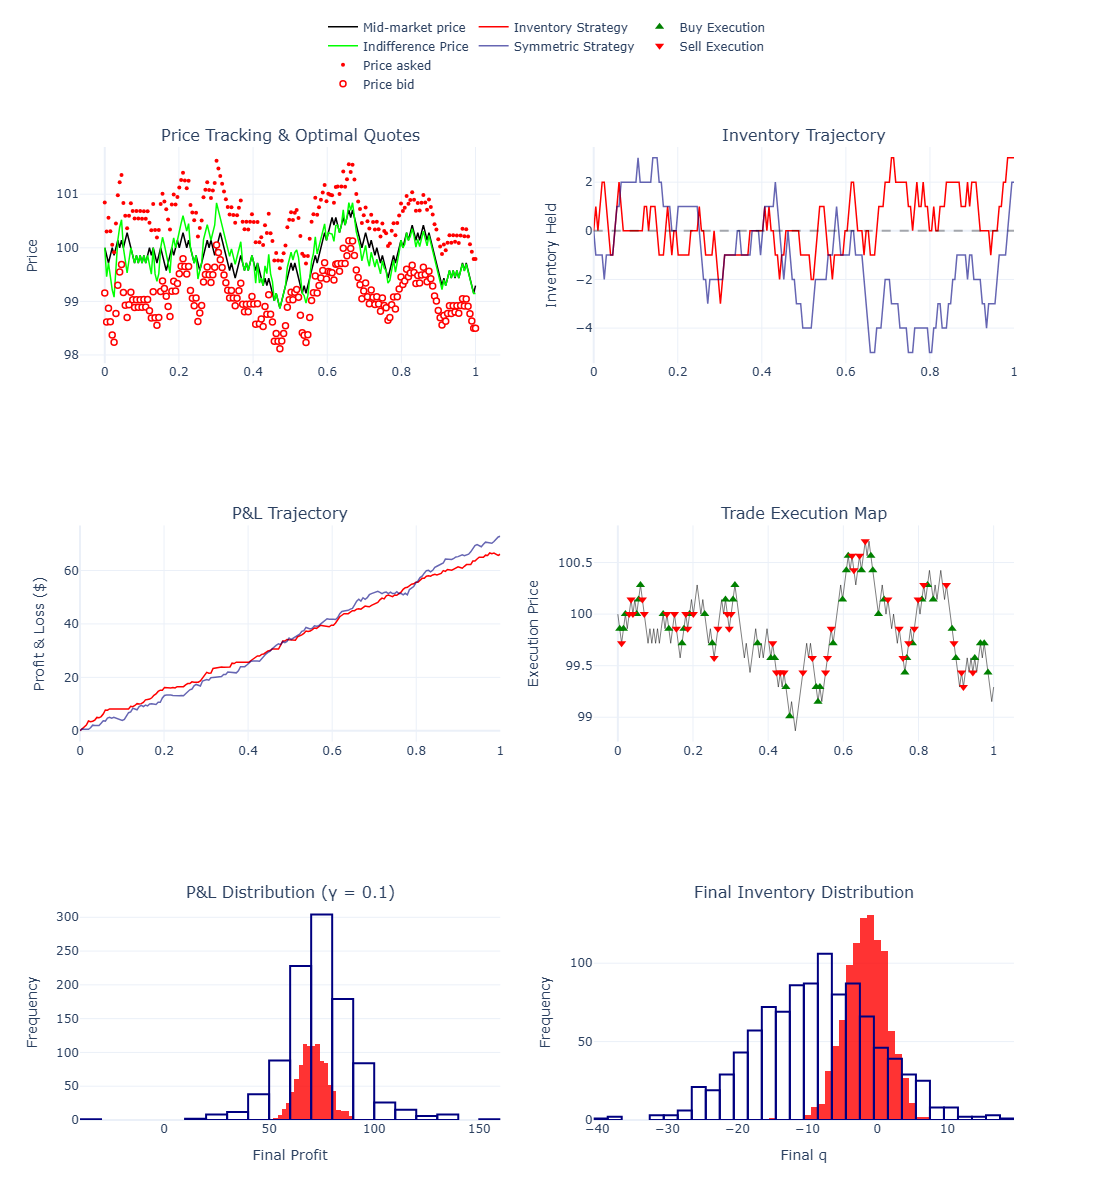

In [12]:
# ==========================================
# SCENARIO: TOXIC ORDER FLOW
# ==========================================
display(HTML("""
<div style='text-align: center; margin-bottom: 20px;'>
    <h2>Scenario: Toxic Order Flow</h2>
    <p><b>Condition:</b> Aggressive buyers arrive 20% faster than sellers (Market Trend).<br>
    Notice how the Symmetric strategy accumulates a massive negative inventory, while the Inventory strategy defends its book.</p>
</div>
"""))

# ask_mult=1.2 simulates heavy buying pressure against the market maker
run_monte_carlo(ask_mult=1.2, bid_mult=1.0, jumps=False, gamma_val=0.1)

## Part 4: Adding Jump-Diffusion (Fat Tails)

Standard Brownian motion ($dW_u$) creates continuous, smooth prices. Real financial markets experience "jumps" (fat tails)—sudden $2.00 price crashes or spikes between ticks.

Running simulations, please wait...


Strategy,Mean Profit,Std Dev (Profit),Mean Final q,Std Dev (Final q),Sharpe Ratio
Inventory,64.332,8.985,-0.014,2.838,7.160
Symmetric,68.820,29.953,-0.187,8.580,2.298


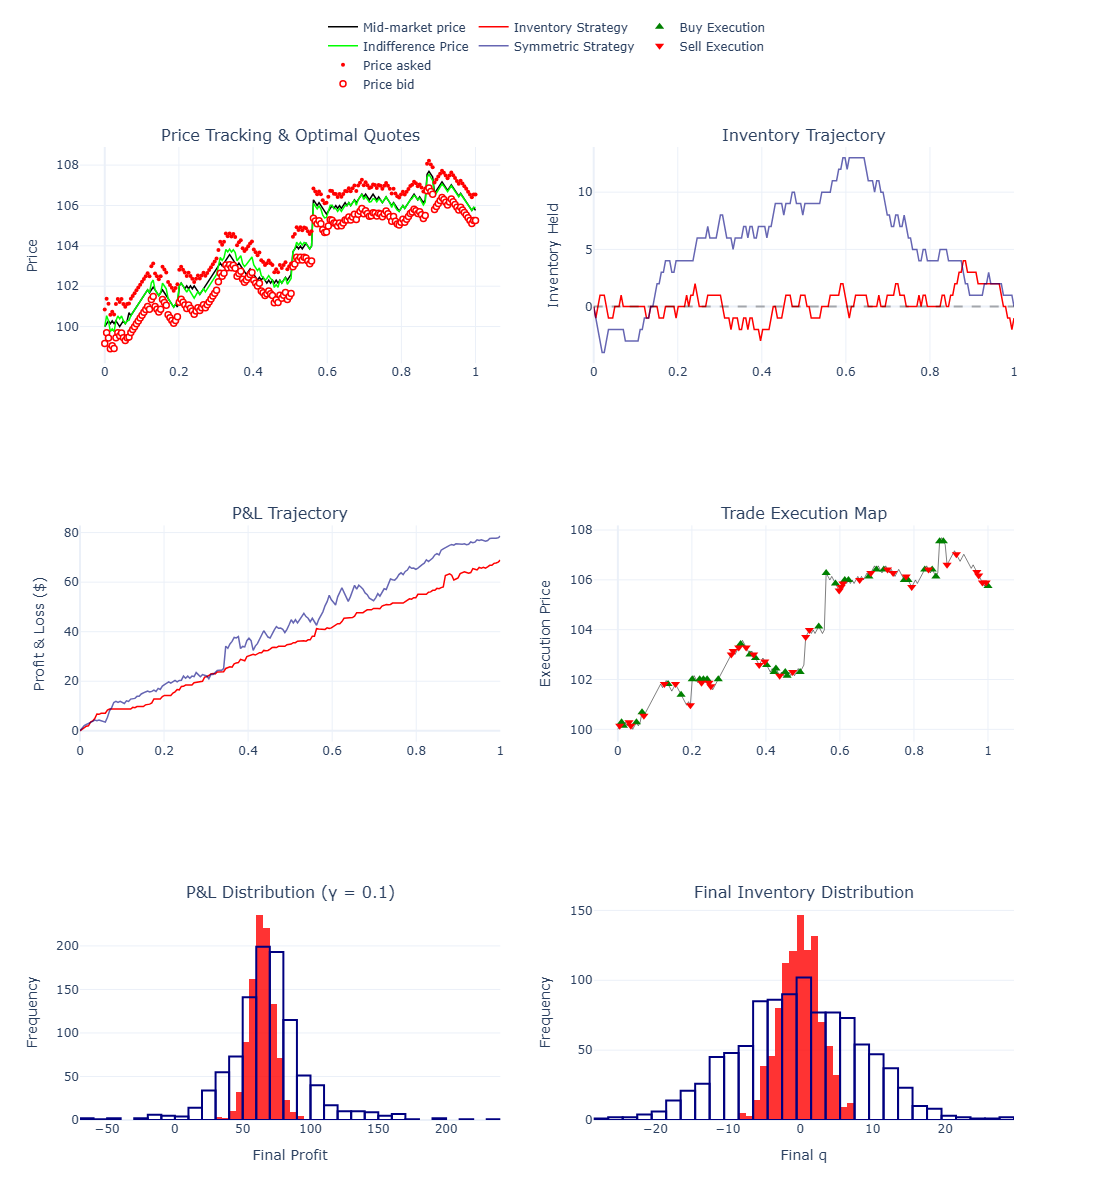

In [13]:
# ==========================================
# SCENARIO: FAT-TAIL JUMP DIFFUSION
# ==========================================
display(HTML("""
<div style='text-align: center; margin-bottom: 20px;'>
    <h2>Scenario: Fat-Tail Jump Diffusion</h2>
    <p><b>Condition:</b> Mid-price experiences sudden, random Poisson jumps.<br>
    Notice how the Symmetric strategy's P&L variance explodes because it is often caught holding large inventory right when a jump occurs.</p>
</div>
"""))

# jumps=True activates the exponential shock generator in the core engine
run_monte_carlo(ask_mult=1.0, bid_mult=1.0, jumps=True, gamma_val=0.1)